In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [3]:
df1 = pd.read_csv("Guwahati_House_Data.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Built-up Area,Ready To Move,Dispur,4 BHK,Uttarayan Harmony,1200,4.0,0.0,78.29
1,Super built-up Area,25-Mar,Sarusajai,1 RK,Fortune Victor,400,1.0,0.0,12.86
2,Super built-up Area,Ready To Move,Khanapara,5 BHK,ADH Chandrama,1309,6.0,3.0,58.48
3,Carpet Area,Ready To Move,Six Mile,3 BHK,KIC Gulmohor,1130,3.0,0.0,64.92
4,Super built-up Area,Ready To Move,Bhetapara,1 Bedroom,S Tower,583,1.0,0.0,18.19


In [4]:
# Rows and columns
df1.shape

(20000, 9)

In [5]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area           4583
Carpet  Area             1015
Plot  Area               2543
Super built-up  Area    11859
Name: area_type, dtype: int64

In [6]:
# assuming these columns do not affect price
df2 = df1.drop(['area_type', 'society', 'balcony', 'availability'], axis='columns')
df2.head()

,location,size,total_sqft,bath,price
0,Dispur,4 BHK,1200,4.0,78.29
1,Sarusajai,1 RK,400,1.0,12.86
2,Khanapara,5 BHK,1309,6.0,58.48
3,Six Mile,3 BHK,1130,3.0,64.92
4,Bhetapara,1 Bedroom,583,1.0,18.19


In [7]:
df2.isnull().sum()

location        0
size          133
total_sqft      0
bath           89
price           0
dtype: int64

In [8]:
# droping null values
df3 = df2.dropna()
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [9]:
# analysing 'size' column
df3['size'].unique()

array(['4 BHK', '1 RK', '5 BHK', '3 BHK', '1 Bedroom', '2 Bedroom',
       '2 BHK', '5 Bedroom', '1 BHK', '6 Bedroom', '3 Bedroom',
       '4 Bedroom', '8 Bedroom', '7 Bedroom', '6 BHK'], dtype=object)

In [10]:
# created a new column named bhk
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

C:\Users\abhin\AppData\Local\Temp\ipykernel_19724\3140489915.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))


In [11]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Dispur,4 BHK,1200,4.0,78.29,4
1,Sarusajai,1 RK,400,1.0,12.86,1
2,Khanapara,5 BHK,1309,6.0,58.48,5
3,Six Mile,3 BHK,1130,3.0,64.92,3
4,Bhetapara,1 Bedroom,583,1.0,18.19,1


In [12]:
# these are the unique values of bhk
df3['bhk'].unique()

array([4, 1, 5, 3, 2, 6, 8, 7])

In [13]:
# these are the unique values of total_sqft
df3.total_sqft.unique()

array(['1200', '400', '1309', ..., '1187-1295', '3758', '3214'],
      shape=(4056,), dtype=object)

In [14]:
# need to convert this range of sqft into an average value
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [15]:
df3[~df3['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
27,RG Baruah Road,1 RK,454-692,1.0,22.69,1
31,Betkuchi,5 BHK,1993-2279,5.0,80.67,5
73,Ulubari,2 Bedroom,732-799,3.0,42.40,2
150,Satgaon,2 BHK,1009-1301,3.0,39.79,2
160,Basistha,5 Bedroom,2317-2453,6.0,60.50,5
194,Bhetapara,1 RK,481-636,1.0,14.86,1
201,Khanapara,3 Bedroom,1186-1483,4.0,69.44,3
205,Pan Bazaar,5 Bedroom,1813-1950,6.0,81.57,5
233,Rukminigaon,1 BHK,625-710,1.0,23.42,1
247,Bamunimaidam,5 Bedroom,3052-3314,5.0,145.90,5


In [16]:
# data cleaning in total_sqft
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return(float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [17]:
# trying the user defined function with data
convert_sqft_to_num('2166')

2166.0

In [18]:
convert_sqft_to_num('2317-2453')

2385.0

In [19]:
convert_sqft_to_num('34.46Sq. Meter')

In [20]:
# copying dataframe
df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Dispur,4 BHK,1200.0,4.0,78.29,4
1,Sarusajai,1 RK,400.0,1.0,12.86,1
2,Khanapara,5 BHK,1309.0,6.0,58.48,5
3,Six Mile,3 BHK,1130.0,3.0,64.92,3
4,Bhetapara,1 Bedroom,583.0,1.0,18.19,1


In [21]:
# checking if the convert_sqft_to_num worked:
df4.loc[160]

location       Basistha
size          5 Bedroom
total_sqft       2385.0
bath                6.0
price              60.5
bhk                   5
Name: 160, dtype: object

In [22]:
(2317+2453)/2

2385.0

In [23]:
# copying and using feature engineering
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Dispur,4 BHK,1200.0,4.0,78.29,4,6524.166667
1,Sarusajai,1 RK,400.0,1.0,12.86,1,3215.000000
2,Khanapara,5 BHK,1309.0,6.0,58.48,5,4467.532468
3,Six Mile,3 BHK,1130.0,3.0,64.92,3,5745.132743
4,Bhetapara,1 Bedroom,583.0,1.0,18.19,1,3120.068611


In [24]:
# now analysing location column
len(df5.location.unique())

83

In [25]:
# so there is not much unique location since ghy is a small city, but lets move forward imagining the unique location is too much.

df5.location = df5.location.apply(lambda x: x.strip())

location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Uzan Bazar      433
Ulubari         427
Zoo Road        424
ABC             423
Khanapara       423
               ... 
Majerhat         88
Hatigarh         87
Sonapur          84
Bongaon Road     80
Jorabat          79
Name: location, Length: 83, dtype: int64

In [26]:
# any location that has less than 10 data points is considered other location
len(location_stats[location_stats<=10])

0

In [27]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10 
# This wouldve shown if there are locations with less than or equal to 10 data points. but since there are none in our dataset so no prblm.

Series([], Name: location, dtype: int64)

In [28]:
len(df5.location.unique())

83

In [29]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df5.location.unique())

83

In [30]:
# Outlier Removal
# Outliers are data points that deviate significantly from the rest of the dataset. They can appear as unusually high or low values and 
# often disrupt the overall distribution of data.

# Unusual Cases
df5[df5.total_sqft/df5.bhk<300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
2,Khanapara,5 BHK,1309.0,6.0,58.48,5,4467.532468
14,Bagharbari,3 BHK,869.0,4.0,22.76,3,2619.102417
16,Zoo Road,5 BHK,1323.0,6.0,55.17,5,4170.068027
35,Bagharbari,5 BHK,1291.0,5.0,37.36,5,2893.880713
40,Rupnagar,3 BHK,865.0,3.0,33.25,3,3843.930636


In [31]:
df5.shape

(19778, 7)

In [32]:
# remove the unusual cases
df6 = df5[~(df5.total_sqft/df5.bhk<300)]
df6.shape

(16770, 7)

In [33]:
df6.price_per_sqft.describe()
# We can see that the min and max is reasonable, hence no outlier removal reqiured, but we'll perform it.

count    16770.000000
mean      3818.799123
std        981.588550
min       1404.094011
25%       3111.477459
50%       3685.157580
75%       4417.773475
max       8886.756238
Name: price_per_sqft, dtype: float64

In [34]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df7 = remove_pps_outliers(df6)
df7.shape

(11370, 7)

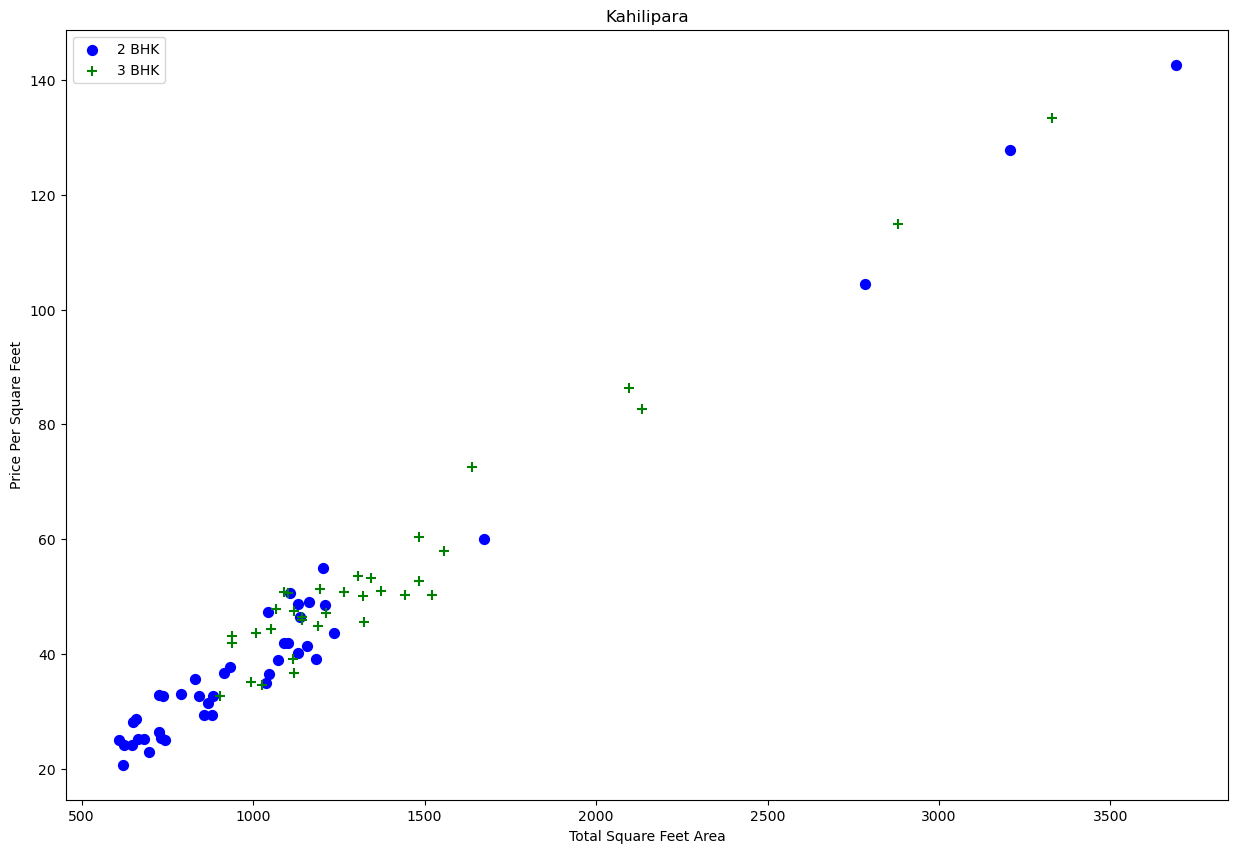

In [35]:
# check to see if the number of 2 bhk home price is more than 3 bhk home price
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, marker='+', color='green', label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price Per Square Feet")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df7, "Kahilipara")

# inspect where 2bhk is higher than 3bhk in a vertical line in the graph

In [36]:
# We should also remove properties where for same location, the price of (for example) 3 bedroom apartments is less than 2 bedroom apartments
# (with same sq ft area). What we will do is for a given location, we will build a dictionary of stats per bhk, i.e.

# {
#     '1' : {
#         'mean':4000,
#         'std': 2000,
#         'count': 34
#     },
#     '2' : {
#         'mean':4300,
#         'std': 2300,
#         'count': 22
#    },
# }

# Now we can remove those 2bhk apartments whose price_per_sqft is less than mean price_per_sqft of 1 bhk

In [37]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std' : np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')

df8 = remove_bhk_outliers(df7)
df8.shape

(6989, 7)

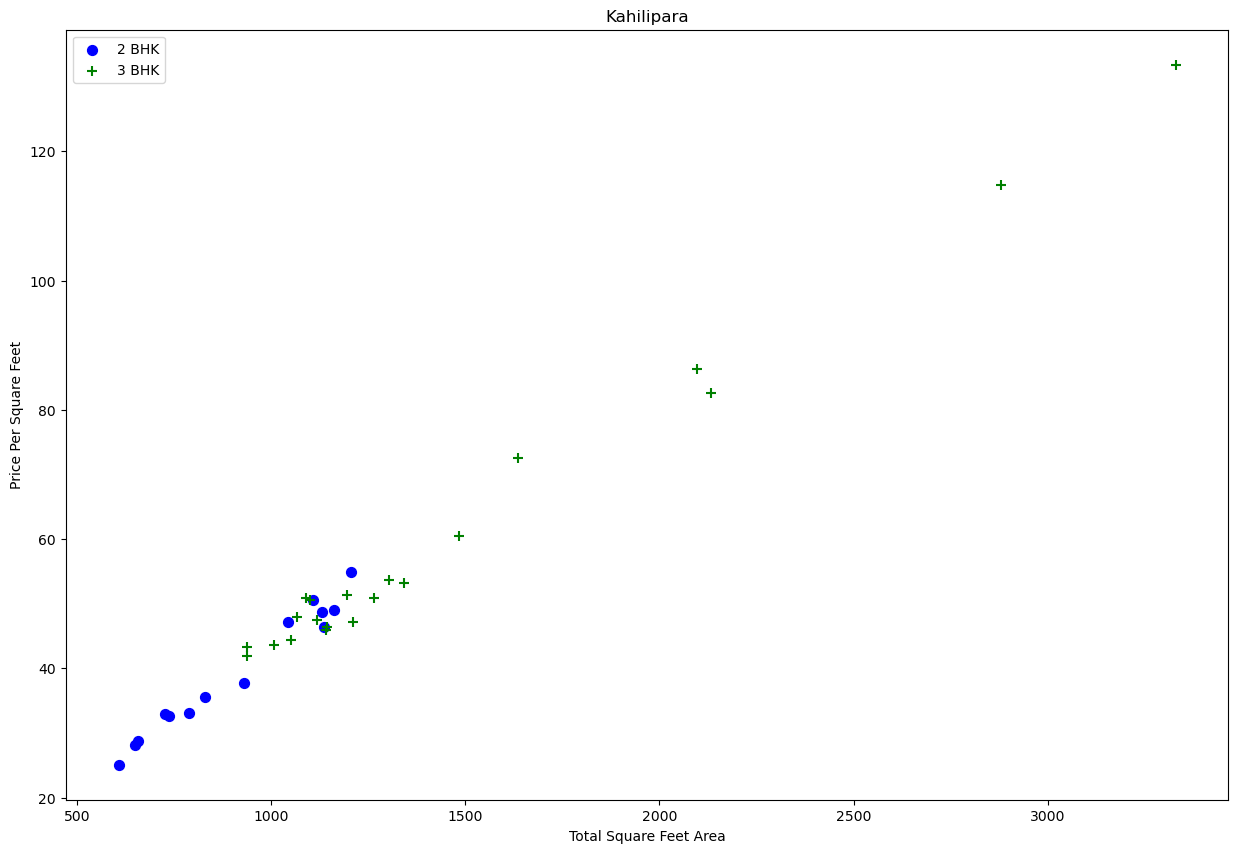

In [38]:
# see the improvement
plot_scatter_chart(df8, "Kahilipara")

Text(0, 0.5, 'Count')

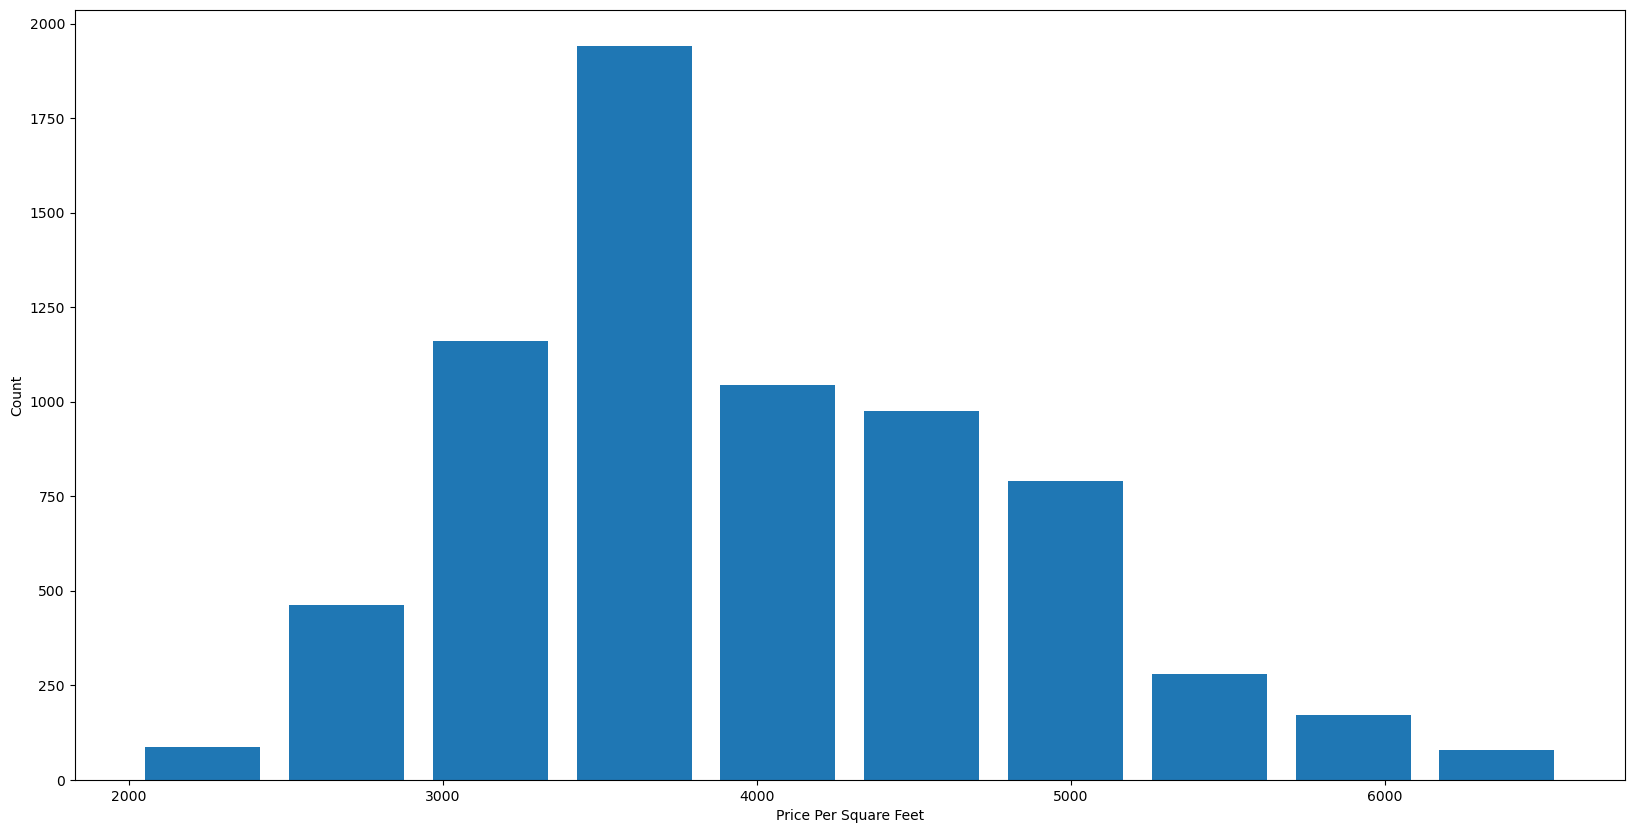

In [39]:
# plot histogram to see how many properties per sqft area
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [40]:
# explore the bathroom feature
df8.bath.unique()

array([5., 2., 4., 3., 1., 6., 7., 9., 8.])

In [41]:
df8[df8.bath>7]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
105,ABC,8 Bedroom,3152.0,9.0,139.55,8,4427.347716
241,ABC,8 Bedroom,2675.0,9.0,95.89,8,3584.672897
270,Ambari,8 Bedroom,2900.0,8.0,123.80,8,4268.965517
340,Ambari,8 Bedroom,2656.0,9.0,126.85,8,4775.978916
376,Ambari,7 Bedroom,2796.0,8.0,133.27,7,4766.452074
...,...,...,...,...,...,...,...
11209,Zoo Tiniali,7 Bedroom,2378.0,8.0,116.52,7,4899.915896
11291,Zoo Tiniali,7 Bedroom,2887.0,8.0,139.39,7,4828.195359
11299,Zoo Tiniali,8 Bedroom,3240.0,8.0,166.07,8,5125.617284
11309,Zoo Tiniali,7 Bedroom,2556.0,8.0,133.17,7,5210.093897


Text(0, 0.5, 'Count')

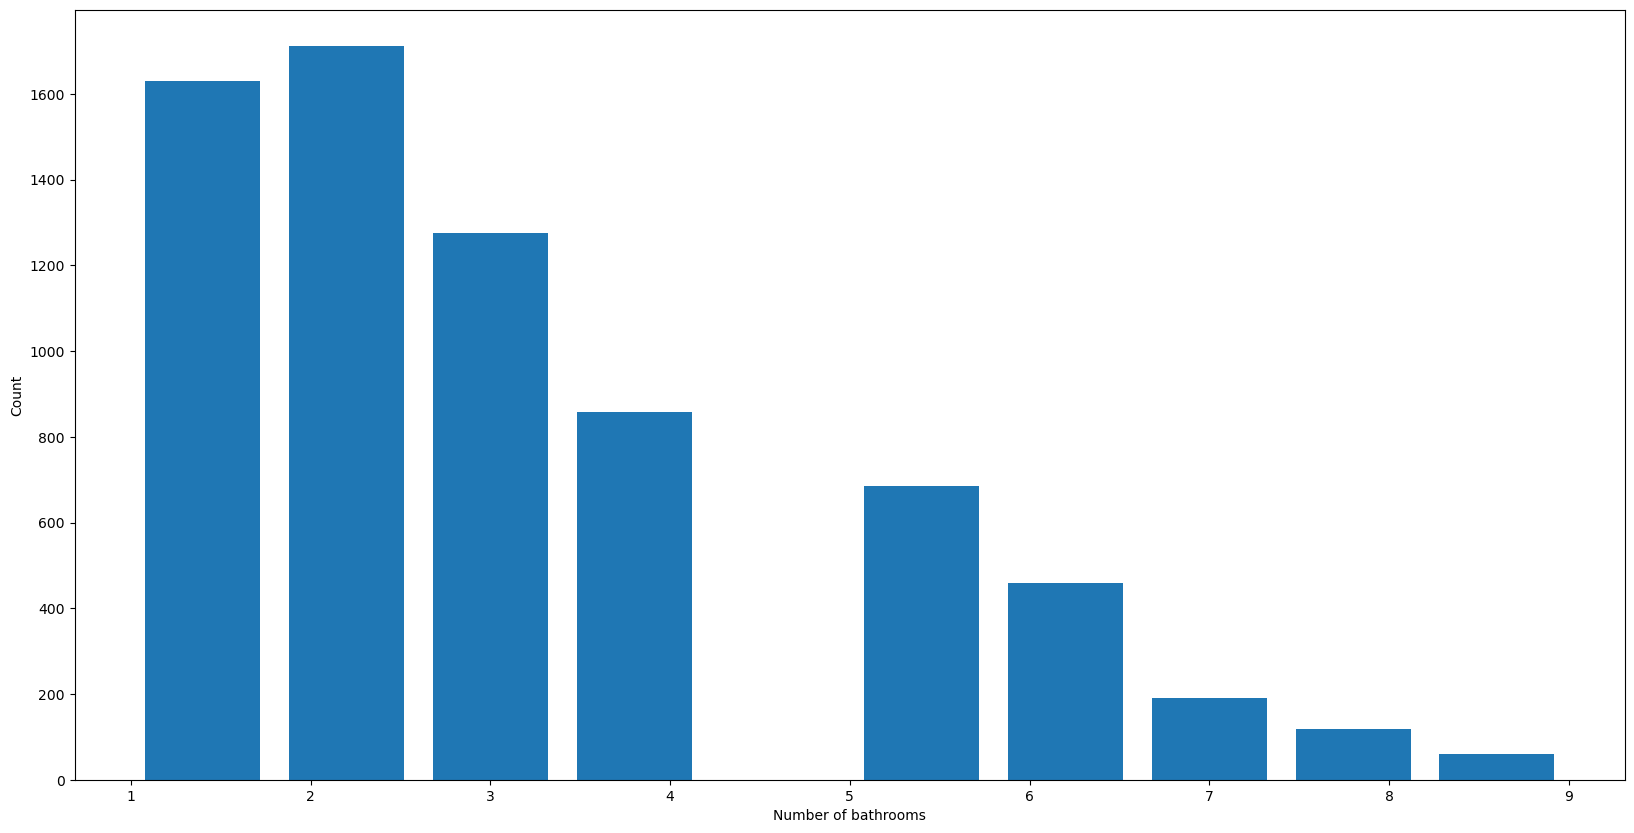

In [42]:
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [43]:
# upon researching we found out when no. of bathrooms is > no. of bedrooms+2, we can mark it as an outlier
df8[df8.bath>df8.bhk+2]
# No outlier found

,location,size,total_sqft,bath,price,bhk,price_per_sqft


In [44]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(6989, 7)

In [45]:
# drop unessecary coulumns
df10 = df9.drop(['size', 'price_per_sqft'], axis='columns')
df10.head()

,location,total_sqft,bath,price,bhk
1,ABC,2262.0,5.0,106.84,5
3,ABC,857.0,2.0,36.23,1
6,ABC,2801.0,4.0,121.32,4
10,ABC,1213.0,3.0,58.56,2
11,ABC,629.0,1.0,29.44,1


In [47]:
# we need to hot encode the location column as it has text in it
dummies = pd.get_dummies(df10['location'], dtyp e=int)
dummies.head()

,ABC,Ambari,Amsing,Azara,Bagharbari,Bamunimaidam,Basistha,Basisthapur,Beharbari,Beltola,...,Six Mile,Sonapur,Sundarpur,Tarun Nagar,Tetelia,Ulubari,Uzan Bazar,VIP Road,Zoo Road,Zoo Tiniali
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
df11 = pd.concat([df10, dummies], axis='columns')
df11.head()

,location,total_sqft,bath,price,bhk,ABC,Ambari,Amsing,Azara,Bagharbari,...,Six Mile,Sonapur,Sundarpur,Tarun Nagar,Tetelia,Ulubari,Uzan Bazar,VIP Road,Zoo Road,Zoo Tiniali
1,ABC,2262.0,5.0,106.84,5,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ABC,857.0,2.0,36.23,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,ABC,2801.0,4.0,121.32,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,ABC,1213.0,3.0,58.56,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,ABC,629.0,1.0,29.44,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
# drop the location column
df12 = df11.drop('location', axis='columns')
df12.head()

,total_sqft,bath,price,bhk,ABC,Ambari,Amsing,Azara,Bagharbari,Bamunimaidam,...,Six Mile,Sonapur,Sundarpur,Tarun Nagar,Tetelia,Ulubari,Uzan Bazar,VIP Road,Zoo Road,Zoo Tiniali
1,2262.0,5.0,106.84,5,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,857.0,2.0,36.23,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2801.0,4.0,121.32,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,1213.0,3.0,58.56,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,629.0,1.0,29.44,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
df12.shape

(6989, 87)

In [52]:
# drop price
X = df12.drop('price', axis='columns')
X.head()

,total_sqft,bath,bhk,ABC,Ambari,Amsing,Azara,Bagharbari,Bamunimaidam,Basistha,...,Six Mile,Sonapur,Sundarpur,Tarun Nagar,Tetelia,Ulubari,Uzan Bazar,VIP Road,Zoo Road,Zoo Tiniali
1,2262.0,5.0,5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,857.0,2.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2801.0,4.0,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,1213.0,3.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,629.0,1.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
y = df12.price
y.head()

1     106.84
3      36.23
6     121.32
10     58.56
11     29.44
Name: price, dtype: float64

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [56]:
# create a linear regression model
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

0.9541307369867953

In [85]:
# using K fold cross val for Linear Regression
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score = cross_val_score(LinearRegression(), X, y, cv=cv)
print(cross_val_score)
cross_val_score.mean()

[0.95507954 0.96127016 0.95718386 0.95606916 0.95812084]


np.float64(0.957544712183924)

In [67]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [68]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['mse', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size = 0.2, random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })
    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

find_best_model_using_gridsearchcv(X,y)

,model,best_score,best_params
0,linear_regression,0.957545,{'fit_intercept': False}
1,lasso,0.883634,"{'alpha': 2, 'selection': 'random'}"
2,decision_tree,0.951134,"{'criterion': 'friedman_mse', 'splitter': 'ran..."


In [103]:
X.columns

Index(['total_sqft', 'bath', 'bhk', 'ABC', 'Ambari', 'Amsing', 'Azara',
       'Bagharbari', 'Bamunimaidam', 'Basistha', 'Basisthapur', 'Beharbari',
       'Beltola', 'Beltola Bazar', 'Beltola Road', 'Betkuchi', 'Bhangagarh',
       'Bhetapara', 'Birubari', 'Bongaon Road', 'Boragaon', 'Borbari',
       'Chandmari', 'Christian Basti', 'Dharapur', 'Dhirenpara', 'Dispur',
       'Fancy Bazaar', 'GNB Road', 'Ganeshguri', 'Garchuk', 'Ghoramara',
       'Gorchuk', 'Gotanagar', 'Hatigaon', 'Hatigarh', 'Hengerabari Road',
       'Hengrabari', 'Jalukbari', 'Jayanagar', 'Jorabat', 'Jyotinagar',
       'Kahilipara', 'Kalapahar', 'Kamakhya', 'Khanapara', 'Krishnanagar',
       'Lachit Nagar', 'Lal Ganesh', 'Lalmati', 'Lokhra', 'Majerhat',
       'Maligaon', 'Mirzapur', 'Nalapara', 'Narengi', 'Narkasur Hill',
       'Navagraha', 'Noonmati', 'North Guwahati', 'Odalbakra', 'Paltan Bazaar',
       'Pan Bazaar', 'Pandu', 'Panjabari', 'Pator Kuchi', 'Pilingkata',
       'RG Baruah Road', 'Rajgarh Road',

In [69]:
# predict price function
def predict_price(location,sqft,bath,bhk):
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >=0:
        x[loc_index] = 1

    return lr_clf.predict([x])[0]

In [98]:
predict_price('Zoo Road', 2000, 2, 2)

np.float64(94.25797305562679)

In [99]:
predict_price('Ulubari', 3700, 3, 1)

np.float64(163.25112529960444)

In [100]:
predict_price('Ulubari', 3700, 3, 2)

np.float64(162.7574248702922)

In [102]:
import pickle
with open('guwahati_house_prices_model.pickle', 'wb') as f:
    pickle.dump(lr_clf, f)

In [105]:
import json
columns = {
    'data_columns': [col.lower() for col in X.columns]
}
with open("columns.json", "w") as f:
    f.write(json.dumps(columns))